<a href="https://colab.research.google.com/github/Pranayshukla0610/ML-projects-portfolio/blob/main/Movie_NLP_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install nltk wordcloud scikit-learn spacy

!python -m nltk.downloader punkt
!python -m nltk.downloader stopwords
!python -m nltk.downloader wordnet
!python -m nltk.downloader averaged_perceptron_tagger
!python -m nltk.downloader maxent_ne_chunker
!python -m nltk.downloader words

!python -m spacy download en_core_web_sm

<frozen runpy>:128: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
<frozen runpy>:128: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
<frozen runpy>:128: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
[nltk_data] Downloading package wordnet to /root/nltk_data...
<frozen runpy>:128: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nl

#IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import string
import spacy

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk import ne_chunk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from wordcloud import WordCloud

print("Libraries Imported Successfully")

Libraries Imported Successfully


#CREATE DATASET


In [3]:
data = {
    'review': [
        'This movie was fantastic and amazing',
        'Worst movie I have ever watched',
        'Absolutely loved the acting and story',
        'Waste of time and money',
        'Excellent direction and screenplay',
        'Terrible experience and boring film',
        'I really enjoyed this movie',
        'Very bad acting and poor script'
    ],

    'sentiment': [
        'positive',
        'negative',
        'positive',
        'negative',
        'positive',
        'negative',
        'positive',
        'negative'
    ]
}

df = pd.DataFrame(data)

df.head()

,review,sentiment
0,This movie was fantastic and amazing,positive
1,Worst movie I have ever watched,negative
2,Absolutely loved the acting and story,positive
3,Waste of time and money,negative
4,Excellent direction and screenplay,positive


#DATASET INFORMATION

In [5]:
print(df.shape)

print(df.info())

print(df['sentiment'].value_counts())

(8, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     8 non-null      object
 1   sentiment  8 non-null      object
dtypes: object(2)
memory usage: 260.0+ bytes
None
sentiment
positive    4
negative    4
Name: count, dtype: int64


#CONVERT TEXT TO LOWER

In [6]:
df['review'] = df['review'].str.lower()

df.head()

,review,sentiment
0,this movie was fantastic and amazing,positive
1,worst movie i have ever watched,negative
2,absolutely loved the acting and story,positive
3,waste of time and money,negative
4,excellent direction and screenplay,positive


#REMOVE PUNCTUATIONS

In [7]:
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

df['review'] = df['review'].apply(remove_punctuation)

df.head()

,review,sentiment
0,this movie was fantastic and amazing,positive
1,worst movie i have ever watched,negative
2,absolutely loved the acting and story,positive
3,waste of time and money,negative
4,excellent direction and screenplay,positive


#REMOVE NUMBERS

In [8]:
def remove_numbers(text):
    return re.sub(r'\d+', '', text)

df['review'] = df['review'].apply(remove_numbers)

df.head()

,review,sentiment
0,this movie was fantastic and amazing,positive
1,worst movie i have ever watched,negative
2,absolutely loved the acting and story,positive
3,waste of time and money,negative
4,excellent direction and screenplay,positive


In [10]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [11]:
df['tokens'] = df['review'].apply(word_tokenize)

df[['review', 'tokens']].head()

,review,tokens
0,this movie was fantastic and amazing,"[this, movie, was, fantastic, and, amazing]"
1,worst movie i have ever watched,"[worst, movie, i, have, ever, watched]"
2,absolutely loved the acting and story,"[absolutely, loved, the, acting, and, story]"
3,waste of time and money,"[waste, of, time, and, money]"
4,excellent direction and screenplay,"[excellent, direction, and, screenplay]"


#STOPWORD REMOVAL

In [12]:
stop_words = set(stopwords.words('english'))

df['tokens'] = df['tokens'].apply(
    lambda x: [word for word in x if word not in stop_words]
)

df[['review', 'tokens']].head()

,review,tokens
0,this movie was fantastic and amazing,"[movie, fantastic, amazing]"
1,worst movie i have ever watched,"[worst, movie, ever, watched]"
2,absolutely loved the acting and story,"[absolutely, loved, acting, story]"
3,waste of time and money,"[waste, time, money]"
4,excellent direction and screenplay,"[excellent, direction, screenplay]"


#STEMMING

In [13]:
stemmer = PorterStemmer()

df['stemmed'] = df['tokens'].apply(
    lambda x: [stemmer.stem(word) for word in x]
)

df[['tokens', 'stemmed']].head()

,tokens,stemmed
0,"[movie, fantastic, amazing]","[movi, fantast, amaz]"
1,"[worst, movie, ever, watched]","[worst, movi, ever, watch]"
2,"[absolutely, loved, acting, story]","[absolut, love, act, stori]"
3,"[waste, time, money]","[wast, time, money]"
4,"[excellent, direction, screenplay]","[excel, direct, screenplay]"


#LEMMATIZER

In [14]:
lemmatizer = WordNetLemmatizer()

df['lemmatized'] = df['tokens'].apply(
    lambda x: [lemmatizer.lemmatize(word) for word in x]
)

df[['tokens', 'lemmatized']].head()

,tokens,lemmatized
0,"[movie, fantastic, amazing]","[movie, fantastic, amazing]"
1,"[worst, movie, ever, watched]","[worst, movie, ever, watched]"
2,"[absolutely, loved, acting, story]","[absolutely, loved, acting, story]"
3,"[waste, time, money]","[waste, time, money]"
4,"[excellent, direction, screenplay]","[excellent, direction, screenplay]"


#POS TAGGING

In [16]:
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [17]:
sample_tokens = df['tokens'].iloc[0]

pos_result = pos_tag(sample_tokens)

print(pos_result)

[('movie', 'NN'), ('fantastic', 'JJ'), ('amazing', 'NN')]


In [19]:
nltk.download('maxent_ne_chunker')
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')

[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


True

#NAMED ENTITY RECOGNITION

In [20]:
sentence = "Elon Musk is the CEO of Tesla"

tokens = word_tokenize(sentence)

pos_tokens = pos_tag(tokens)

ner_result = ne_chunk(pos_tokens)

print(ner_result)

(S
  (PERSON Elon/NNP)
  (ORGANIZATION Musk/NNP)
  is/VBZ
  the/DT
  (ORGANIZATION CEO/NN of/IN Tesla/NNP))


#JOIN TEXT

In [21]:
df['clean_text'] = df['lemmatized'].apply(lambda x: " ".join(x))

df[['clean_text']].head()

,clean_text
0,movie fantastic amazing
1,worst movie ever watched
2,absolutely loved acting story
3,waste time money
4,excellent direction screenplay


#WORDCLOUD VISUALIZATION

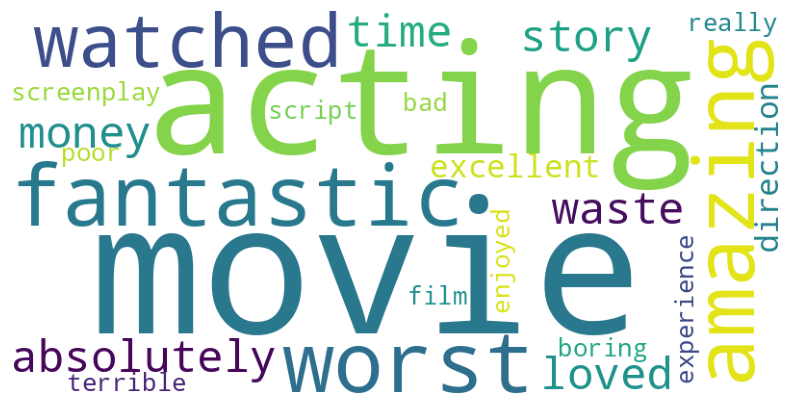

In [22]:
text = " ".join(df['clean_text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()

#BAG OF WORDS

In [23]:
cv = CountVectorizer()

X_bow = cv.fit_transform(df['clean_text'])

print(cv.get_feature_names_out())

print(X_bow.toarray())

['absolutely' 'acting' 'amazing' 'bad' 'boring' 'direction' 'enjoyed'
 'ever' 'excellent' 'experience' 'fantastic' 'film' 'loved' 'money'
 'movie' 'poor' 'really' 'screenplay' 'script' 'story' 'terrible' 'time'
 'waste' 'watched' 'worst']
[[0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1]
 [1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0]
 [0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0]
 [0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0]]


#TFIDF Vectorizer

In [24]:
tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df['clean_text'])

print(tfidf.get_feature_names_out())

print(X.toarray())

['absolutely' 'acting' 'amazing' 'bad' 'boring' 'direction' 'enjoyed'
 'ever' 'excellent' 'experience' 'fantastic' 'film' 'loved' 'money'
 'movie' 'poor' 'really' 'screenplay' 'script' 'story' 'terrible' 'time'
 'waste' 'watched' 'worst']
[[0.         0.         0.62956522 0.         0.         0.
  0.         0.         0.         0.         0.62956522 0.
  0.         0.         0.4552969  0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.53277424 0.         0.         0.         0.
  0.         0.         0.38529838 0.         0.         0.
  0.         0.         0.         0.         0.         0.53277424
  0.53277424]
 [0.51970849 0.43555627 0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.51970849 0.         0.         0.         0.         0.
  0.         0.51970849 0.         0.         0.         0.
  0. 

#ENCODE TARGET VARIABLE

In [25]:
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

y = df['sentiment']

print(y)

0    1
1    0
2    1
3    0
4    1
5    0
6    1
7    0
Name: sentiment, dtype: int64


#TRAIN TEST SPLIT

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(6, 25)
(2, 25)


#TRAIN LOGISTIC REGRESSION MODEL

In [27]:

model = LogisticRegression()

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


#PREDICTION

In [28]:
y_pred = model.predict(X_test)

print(y_pred)

[1 1]
